# SMOS系统模型与基础知识笔记
这篇笔记旨在尽可能完整的记录SMOS的系统模型与基础知识

> HUST EIC UCSB ECE 罗源凯
> 
> 2025 May
>
> Santa Barbara, CA, USA
>
> A Signal Process Perspective 

## 1. 系统模型
### 1.1 信号接收
SMOS任务的MIRAS仪器由三个连接到中央枢纽的可展开臂组成。对于 SMOS，中心轮毂直径为 1.3 m，三个臂的直径最大可达 8 m。臂均匀分布，角度间隔为 120°。每个臂由三个部分组成，每个部分包含六个 L 波段辐射计。每个臂中的 18 个辐射计与中央集线器中的另外 4 个辐射计相补充，总共 66 个辐射计，其中 12 个在集线器中，54 个在臂中。由于其设计，这些辐射计被称为轻量级、经济高效的前端 (LICEF)（每个 LICEF 天线单元是一个双极化贴片天线）。此外，中央枢纽还放置了三个噪声注入辐射计 (NIR)。包含 NIR 是为了完成校准概念。每个 NIR 还充当放置在同一位置的两个不同的 LICEF（一个通道接收地面辐射（和LICEF功能相同），另一个通道接收注入的参考噪声信号，用于定标。）。实际上，每个 NIR 由两个耦合到单个天线的 LICEF 接收器组成。因此，MIRAS 总共包含 69 个天线（用于 66 个 LICEF 和 3 个 NIR）以及 72 个接收器（66 个 LICEF 加上 6 个用于 NIR）。这也解释了为什么 l1a阵列数据的维度是 2556 x 2， NIR数据是 12 x 1。

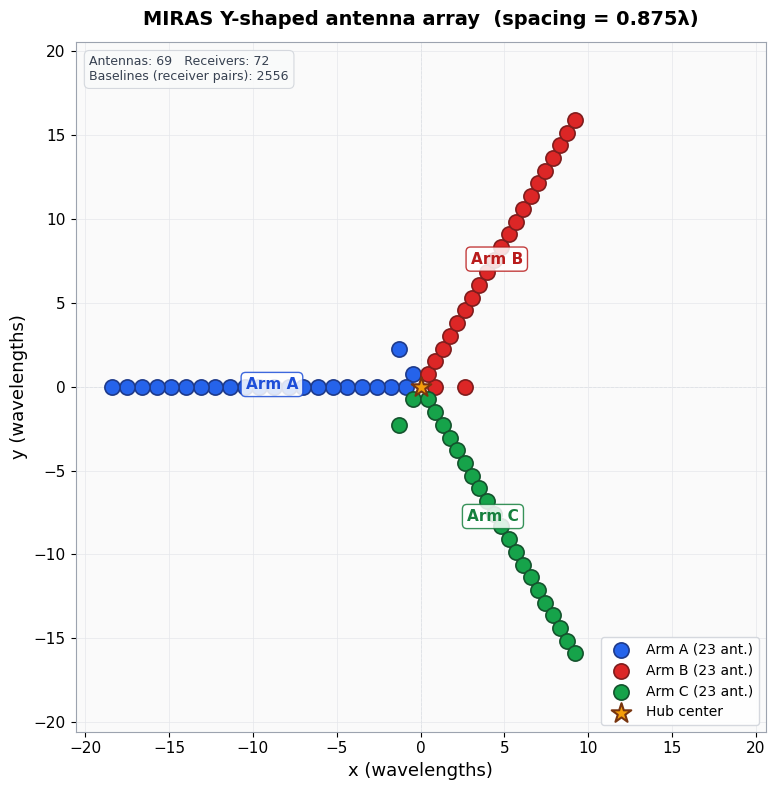

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def compute_antenna_positions(ant_min_space=0.875):
    # A臂：sub_A（5个）+ arm_A（18个）
    arm_A = np.array([-(j - 2) * ant_min_space for j in range(6, 24)], dtype=complex)

    sub_A = np.zeros(5, dtype=complex)
    sub_A[0] = 3 * ant_min_space * np.exp(1j * 2 * np.pi / 3)
    sub_A[1] = 1 * ant_min_space * np.exp(1j * 2 * np.pi / 3)
    for j in range(3, 6):
        sub_A[j - 1] = -(j - 2) * ant_min_space

    A = np.concatenate([sub_A, arm_A])        # 23个
    B = A * np.exp(-1j * 2 * np.pi / 3)       # 旋转-120°
    C = B * np.exp(-1j * 2 * np.pi / 3)       # 再旋转-120°

    return A, B, C


def plot_antenna_array(ant_min_space=0.875):
    A, B, C = compute_antenna_positions(ant_min_space)

    fig, ax = plt.subplots(figsize=(8, 8))
    fig.patch.set_facecolor('white')

    colors = {
        'A': ('#2563EB', '#1E40AF'),  # (face, edge)
        'B': '#DC2626',
        'C': '#16A34A',
    }

    # 绘制三臂
    for arm, label, fc, ec in [
        (A, 'Arm A (23 ant.)', '#2563EB', '#1E3A8A'),
        (B, 'Arm B (23 ant.)', '#DC2626', '#7F1D1D'),
        (C, 'Arm C (23 ant.)', '#16A34A', '#14532D'),
    ]:
        ax.scatter(arm.real, arm.imag, s=120,
                   facecolors=fc, edgecolors=ec,
                   linewidths=1.2, zorder=3, label=label)

    # 中心hub标记
    ax.scatter([0], [0], s=220, marker='*',
               facecolors='#F59E0B', edgecolors='#78350F',
               linewidths=1.5, zorder=5, label='Hub center')

    # 臂标签
    for arm, label, color in [
        (A, 'Arm A', '#1D4ED8'),
        (B, 'Arm B', '#B91C1C'),
        (C, 'Arm C', '#15803D'),
    ]:
        cx, cy = arm.real.mean(), arm.imag.mean()
        ax.text(cx, cy, label, fontsize=11, fontweight='bold',
                color=color, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='white', edgecolor=color,
                          alpha=0.85, linewidth=1))

    # 参考线
    all_pos = np.concatenate([A, B, C])
    max_val = np.max(np.abs(np.concatenate([all_pos.real, all_pos.imag]))) * 1.12
    ax.axhline(0, color='#D1D5DB', linewidth=0.6, linestyle='--', zorder=1)
    ax.axvline(0, color='#D1D5DB', linewidth=0.6, linestyle='--', zorder=1)

    # 统计信息注释
    n_ant = 69
    n_recv = 72
    n_baselines = n_recv * (n_recv - 1) // 2
    info = (f'Antennas: {n_ant}   Receivers: {n_recv}\n'
            f'Baselines (receiver pairs): {n_baselines}')
    ax.text(0.02, 0.98, info, transform=ax.transAxes,
            fontsize=9, va='top', ha='left',
            color='#374151',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='#F9FAFB', edgecolor='#D1D5DB',
                      alpha=0.9, linewidth=0.8))

    # 样式
    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)
    ax.set_aspect('equal')
    ax.set_xlabel('x (wavelengths)', fontsize=13)
    ax.set_ylabel('y (wavelengths)', fontsize=13)
    ax.set_title(f'MIRAS Y-shaped antenna array  '
                 f'(spacing = {ant_min_space:.3f}λ)',
                 fontsize=14, fontweight='bold', pad=12)
    ax.grid(True, color='#E5E7EB', linewidth=0.5, linestyle='-')
    ax.set_facecolor('#FAFAFA')
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color('#9CA3AF')
    ax.legend(loc='lower right', fontsize=10,
              framealpha=0.9, edgecolor='#D1D5DB')
    ax.tick_params(labelsize=11)

    plt.tight_layout()
    plt.show()

    return A, B, C


# 运行
A, B, C = plot_antenna_array(ant_min_space=0.875)

干涉仪测量的不是电场强度，而是两两对天线信号的相关性，这里引入基线的概念：基线是指两个天线之间的距离向量。具体而言，对于二维基线 $(u, v)$ 定义为：$$u_{ij} = \frac{x_i - x_j}{\lambda}, \quad v_{ij} = \frac{y_i - y_j}{\lambda}$$

这里的分母起到的是归一化的作用。

Y型阵列的等效干涉孔径（基线图）应该为：


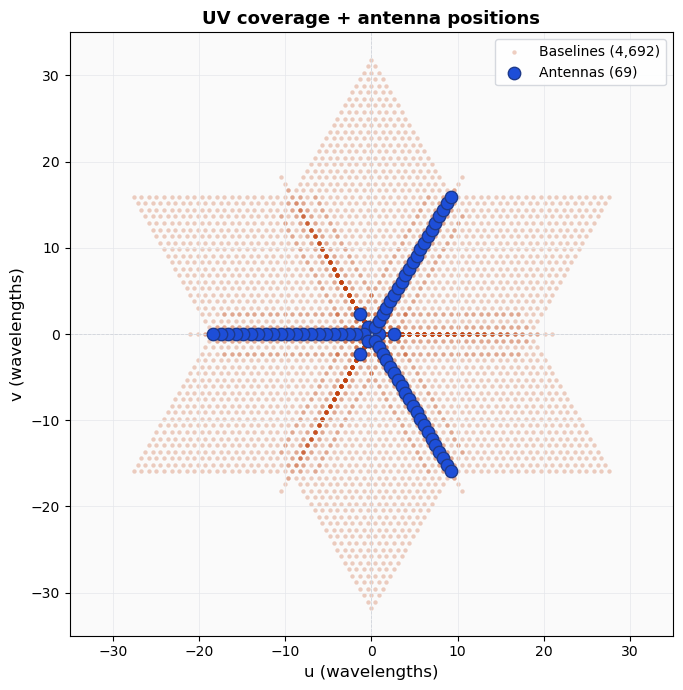

In [5]:
def plot_uv_coverage(ant_min_space=0.875):
    A, B, C = compute_antenna_positions(ant_min_space)
    ant_pos = np.concatenate([A, B, C])
    ant_num = len(ant_pos)

    # 计算基线向量
    n_baselines = ant_num * (ant_num - 1) // 2
    UV_redun = np.zeros(n_baselines, dtype=complex)
    index = 0
    for i in range(ant_num):
        for j in range(i + 1, ant_num):
            UV_redun[index] = ant_pos[i] - ant_pos[j]
            index += 1

    UV_redun_conj = np.concatenate([UV_redun, -UV_redun])

    x_base = UV_redun_conj.real
    y_base = UV_redun_conj.imag
    x_ant  = ant_pos.real
    y_ant  = ant_pos.imag

    fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')

    ax.scatter(x_base, y_base, s=10, color='#C2410C',
               alpha=0.25, linewidths=0,
               label=f'Baselines ({len(UV_redun_conj):,})')
    ax.scatter(x_ant, y_ant, s=80,
               facecolors='#1D4ED8', edgecolors='#1E3A8A',
               linewidths=1.0, zorder=5,
               label=f'Antennas ({ant_num})')

    max_val = np.max(np.abs(np.concatenate([x_base, y_base,
                                            x_ant,  y_ant]))) * 1.1
    ax.axhline(0, color='#D1D5DB', linewidth=0.6, linestyle='--')
    ax.axvline(0, color='#D1D5DB', linewidth=0.6, linestyle='--')
    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)
    ax.set_aspect('equal')
    ax.set_xlabel('u (wavelengths)', fontsize=12)
    ax.set_ylabel('v (wavelengths)', fontsize=12)
    ax.set_title('UV coverage + antenna positions', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10, framealpha=0.9, edgecolor='#D1D5DB')
    ax.grid(True, color='#E5E7EB', linewidth=0.5)
    ax.set_facecolor('#FAFAFA')
    ax.tick_params(labelsize=10)

    plt.tight_layout()
    plt.show()

    return UV_redun_conj, ant_pos


UV_redun_conj, ant_pos = plot_uv_coverage(ant_min_space=0.875)

这里提出一个问题：为什么两个天线接收到的信号做时间平均的相关，得到的信号的物理意义是什么？
这里进行一个数学模型建立与物理意义证明：（相关如何推导得到频域特征）
设地面上有一个**扩展**的非相干辐射源，用亮温分布$T_B(\theta)$表示，从平面波的角度分析天线对的接收信号：

天线 $i$ 位于原点，天线 $j$ 位于 $\vec{b}$（基线向量，$|\vec{b}| = d$），则天线 $j$ 收到的信号相比 $i$ 多走了路程：$$\Delta r = \vec{b} \cdot \hat{n}(\theta) = d \sin \theta$$ （为了数学上的便利，$j$ 也在 $x$ 轴上）

对应几何时延：$$\tau_g = \frac{d \sin \theta}{c} = \frac{d \sin \theta}{\lambda f_0}$$

由于地面是非相干扩展源，把它分解成无穷多个独立的点辐射源，我们可以把每个方向 $\theta$ 的辐射建模为一个平稳随机过程 $s(\theta, t)$，由于非相干性，得到：

$$\langle s(\theta, t) \cdot s^*(\theta', t) \rangle = T_B(\theta) \cdot \delta(\theta - \theta')$$

注意，这里的$T_B(\theta)$表示的亮温实际上就是每个方向$\theta$的功率谱密度。

两个天线接收的信号分别是所有方向辐射的叠加：

$$V_i(t) = \int s(\theta, t) \, d\theta$$
$$V_j(t) = \int s(\theta, t - \tau_g) \, d\theta = \int s\left(\theta, t - \frac{d \sin \theta}{c}\right) d\theta$$

定义，两个天线接收信息的互相关函数：

$$\tilde{V}_{ij} = \langle V_i(t) \cdot V_j^*(t) \rangle$$

代入：

$$\tilde{V}_{ij} = \left\langle \int s(\theta, t) \, d\theta \cdot \int s^*(\theta', t - \tau_g(\theta')) \, d\theta' \right\rangle$$

平稳：
$$\tilde{V}_{ij} = = \iint \langle s(\theta, t) \cdot s^*(\theta', t - \tau_g(\theta')) \rangle \, d\theta \, d\theta'$$

非相干性下的自相关：
$$\langle s(\theta, t) \cdot s^*(\theta', t - \tau) \rangle = T_B(\theta) \cdot \delta(\theta - \theta') \cdot R(\tau)$$

这里的信号传递是一维的，扩展到二维球面：
$$\langle s(\mathbf{\hat{n}}, t) \cdot s^*(\mathbf{\hat{n}}', t - \tau) \rangle = T_B(\mathbf{\hat{n}}) \cdot \delta(\mathbf{\hat{n}} - \mathbf{\hat{n}}') \cdot R(\tau)$$

$\mathbf{\hat{n}}$： 这是一个矢量，通常用球面坐标表示为 $(\theta, \phi)$

1. 维纳-辛钦定理的应用与自相关函数推导

   维纳-辛钦定理：对于宽平稳随机过程（WSS），
   其自相关函数 $R(\tau)$ 与功率谱密度（PSD） $S(f)$ 构成傅里叶变换对：
   $$S(f) = \int_{-\infty}^{\infty} R(\tau) e^{-i 2 \pi f \tau} \, d\tau \rightleftharpoons R(\tau) = \int_{-\infty}^{\infty} S(f) e^{i 2 \pi f \tau} \, df$$
   在 SMOS 系统的 L 波段接收机中，信号通过一个中心频率为 $f_0 = 1.4135 \text{ GHz}$，带宽为 $B = 19 \text{ MHz}$ 的带通滤波器。
   假设带内功率谱近似平坦（白噪声假设），则滤波后的功率谱可表示为：
   $$S_{\text{filtered}}(f) = S_0 \cdot \text{rect}\left( \frac{|f| - f_0}{B} \right)$$
   考虑到解析信号（Complex Analytic Signal）表示，我们仅考虑正频率部分，滤波后的复自相关函数为：
   $$R(\tau) = \int_{f_0 - B/2}^{f_0 + B/2} S_0 \cdot e^{i 2 \pi f \tau} \, df$$
   令 $f = f_0 + \nu$，则 $d\nu = df$，积分区间变为 $[-B/2, B/2]$：
   $$R(\tau) = S_0 \int_{-B/2}^{B/2} e^{i 2 \pi (f_0 + \nu) \tau} \, d\nu = S_0 e^{i 2 \pi f_0 \tau} \int_{-B/2}^{B/2} e^{i 2 \pi \nu \tau} \, d\nu$$
   利用 $\text{sinc}$ 函数定义 $\text{sinc}(x) = \frac{\sin(\pi x)}{\pi x}$，
   积分结果为：
   $$R(\tau) = S_0 B \cdot \text{sinc}(B \tau) \cdot e^{i 2 \pi f_0 \tau}$$
   该结果包含两个关键因子：包络项（慢变）： $r(\tau) = \text{sinc}(B \tau)$，即归一化的边缘清洗函数（Fringe Washing Function）。相位项（快变）： $e^{i 2 \pi f_0 \tau}$，由中心频率决定的干涉条纹相位。
2. 边缘清洗效应（Fringe Washing Effect）分析

    对于 SMOS 系统：相干长度（第一零点）： $\tau_{null} = \frac{1}{B} \approx 52.6 \text{ ns}$。
    最大几何时延： 对于最大基线 $d_{\max} \approx 7.7 \text{ m}$，
    最大时延 $\tau_{g, \max} = \frac{d_{\max}}{c} \approx 25.7 \text{ ns}$。
    由于 $\tau_{g, \max}$ 达到了 $\tau_{null}$ 的约一半，$\text{sinc}(B \tau)$ 
    在边缘视场的值约为 $\text{sinc}(0.5) \approx 0.637$。
    结论：不能直接将 $\text{sinc}(B \tau)$ 近似为 1。 这意味着观测到的可见度函数（Visibility）会随基线长度和源的角度发生幅度衰减。
    但是最终只看AF-FOV区域的话，对于最大基线 $d_{\max} \approx 7.7 \text{ m}$，在 $\xi = 0.32$ 处的时延为：$$\tau_g = \frac{d_{\max} \cdot \xi}{c} = \frac{7.7 \times 0.32}{3 \times 10^8} \approx \mathbf{8.2 \text{ ns}}$$
    衰减因子 $\text{sinc}(B\tau_g)$：带宽 $B = 19 \text{ MHz}$：$$\text{sinc}(19 \times 10^6 \times 8.2 \times 10^{-9}) = \text{sinc}(0.156) \approx \mathbf{0.96}$$

    所以总的而言AFFOV确实存在边缘衰减，但衰减程度较小（约4%），可以近似认为是一个常数。
    这么看确实我们论文中的假设是站得住脚的

3. 可见度函数（Visibility Function）的完整表达式

    在干涉测量中，基线对 $(i, j)$ 观测到的可见度 $\tilde{V}_{ij}$ 是互相关函数的空间积分。
    定义方向余弦 $(\xi, \eta)$，其中 $\xi = \sin \theta \cos \phi, \eta = \sin \theta \sin \phi$，注意：单位圆上已知$xi$和$eta$,则$\gamma$已知
    
    几何时延可表示为：$$\tau_g = \frac{u\xi + v\eta}{f_0}$$其中 $(u, v)$ 是以波长为单位的基线坐标。
    将 $R(\tau)$ 代入基线响应积分，得到：(球面积分)
    $$\tilde{V}(u, v) = \iint_{\xi^2+\eta^2 \leq 1} \frac{T_B(\xi, \eta)}{\sqrt{1-\xi^2-\eta^2}} \cdot \underbrace{\text{sinc}(B \tau_g)}_{\text{Fringe Washing}} \cdot e^{-i 2 \pi (u\xi + v\eta)} \, d\xi d\eta$$
    如果定义有效亮度温度（Effective Brightness Temperature）：
    $$T_B^{\text{eff}}(\xi, \eta; u, v) = T_B(\xi, \eta) \cdot \text{sinc}\left( B \frac{u\xi + v\eta}{f_0} \right)$$
    则可见度函数可以写为类傅里叶变换的形式：$$\tilde{V}(u, v) = \mathcal{F} \left\{ \frac{T_B^{\text{eff}}(\xi, \eta; u, v)}{\sqrt{1-\xi^2-\eta^2}} \right\}$$

所以l1a直接进行傅立叶得到的T_B一定是存在误差的不准确模型（不只是边缘衰减），SMOS系统中Vibility到亮温（l1a到l1b）的转换会用系统响应矩阵补偿，从而减小误差。

而且上述计算的坐标系中心是天线阵列的中心，而不是地面场景的中心，所以还需要进行坐标变换（l1b->l1c），大致需要经过姿态旋转，射线与椭球交点，经纬度映射等步骤，才能得到最终的亮温分布。（笛卡尔到地理坐标）



## 2. 数据处理（l10->l1a->l1b->l1c）


## Appendix
### References
[1] Y. H. Kerr et al., “The SMOS mission: New tool for monitoring key elements ofthe global water cycle,” Proc. IEEE, vol. 98, no. 5, pp. 666–687, May 2010.
[2] K. D. McMullan et al., "SMOS: The Payload," in IEEE Transactions on Geoscience and Remote Sensing, vol. 46, no. 3, pp. 594-605, March 2008.